# Lecture 07 : 3개 모델 한 번에 비교 

- 3개 모델 Flatten GAP Conv1D을  정의 → 학습 → 비교합니다.

- 모델마다 하이퍼파라미터(임베딩 차원 포함)가 따로 있어서, 특정 모델만 튜닝하고 싶으면 그 변수만
  바꾸면 됩니다.
- Embedding(mask_zero=True) 하나로 PAD를 자동 처리합니다


In [1]:
!pip install -q koreanize-matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*does not support masking.*")

## 1. 저장된 파일 불러오기

In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/hongsukyi/DL4NLP/main/notebooks/data.npz"
urllib.request.urlretrieve(url, "data.npz")

('data.npz', <http.client.HTTPMessage at 0x2315bc98b90>)

In [4]:
data = np.load("data.npz", allow_pickle=True)

In [5]:
ids = data["input_ids"]
y   = data["labels"]

idx_tr  = data["train_idx"]
idx_val = data["val_idx"]
idx_te  = data["test_idx"]

vocab_size = int(data["vocab_size"])
max_len    = int(data["max_len"])
n_cls      = int(data["num_classes"])
pad_id     = int(data["pad_id"])
classes    = data["class_names"].tolist()

X_tr,  y_tr  = ids[idx_tr],  y[idx_tr]
X_val, y_val = ids[idx_val], y[idx_val]
X_te,  y_te  = ids[idx_te],  y[idx_te]

print("train/val/test:", len(X_tr), len(X_val), len(X_te))
print("classes:", classes)

# Embedding(mask_zero=True)는 "PAD의 토큰 ID가 0"이라고 가정합니다. 실제로 그런지 확인합니다.
assert pad_id == 0, f"pad_id가 0이 아닙니다({pad_id}). mask_zero=True를 그대로 쓰면 안 됩니다."
print("pad_id:", pad_id, "-> mask_zero=True 사용 가능")

train/val/test: 1680 360 360
classes: ['면접', '학교', '협상']
pad_id: 0 -> mask_zero=True 사용 가능


## 2. 공통 준비물 + 모델별 하이퍼파라미터

- Embedding(vocab_size, dim, mask_zero=True)가 PAD(ID=0)
위치를 자동으로 찾아서 이후 층에 '여긴 무시하라'고 알려줍니다.

In [6]:
emb_dim = 128  # 임베딩 차원 

# ---- 모델별 하이퍼파라미터 ----
flat_dense   = 64
gap_dense    = 64
conv_filters = 64
conv_kernel  = 3

In [7]:
def fit_model(model, name):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    h = model.fit(
        X_tr, y_tr, validation_data=(X_val, y_val),
        batch_size=32, epochs=30, callbacks=[es], verbose=2,
    )
    return h
 

In [8]:
   
res = {}
def show_result(model, h, name):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    ax[0].plot(h.history["loss"], label="train"); ax[0].plot(h.history["val_loss"], label="val")
    ax[0].set_title(f"{name} - Loss"); ax[0].legend()
    ax[1].plot(h.history["accuracy"], label="train"); ax[1].plot(h.history["val_accuracy"], label="val")
    ax[1].set_title(f"{name} - Accuracy"); ax[1].legend()
    plt.tight_layout(); plt.show()

    pred = model.predict(X_te, verbose=0).argmax(axis=1)
    acc = (pred == y_te).mean()
    res[name] = {
        "loss": h.history["loss"], "val_loss": h.history["val_loss"],
        "acc": h.history["accuracy"], "val_acc": h.history["val_accuracy"],
        "pred": pred.tolist(), "test_acc": float(acc),
    }
    print(f"[{name}] Test Accuracy: {acc:.3f}")

    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.xticks(range(n_cls), classes); plt.yticks(range(n_cls), classes)
    for i in range(n_cls):
        for j in range(n_cls):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.title(f"{name} - Confusion Matrix"); plt.xlabel("예측"); plt.ylabel("정답")
    plt.tight_layout(); plt.show()

    feat_model = keras.Model(model.input, model.get_layer("feat").output)
    feat = feat_model.predict(X_te, verbose=0)
    xy = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30, n_jobs=1).fit_transform(feat)

    plt.figure(figsize=(5, 3))
    for c in range(n_cls):
        m = y_te == c
        plt.scatter(xy[m, 0], xy[m, 1], s=12, label=classes[c])
    plt.title(f"{name} - t-SNE"); plt.legend()
    plt.tight_layout(); plt.show()

## 3. 모델 정의하기 

- Embedding(..., mask_zero=True) 한 줄로 PAD 처리가 끝납니다.
-  Conv1D는 마스킹을 지원하지 않기 때문에 keras.ops로 직접 계산한 값을 더해서 PAD를 밀어냅니다.

In [9]:
def build_flatten(emb_dim):
    inp = keras.Input((max_len,))
    x = layers.Embedding(vocab_size, emb_dim, mask_zero=True)(inp)
    x = layers.Flatten()(x)
    x = layers.Dense(flat_dense, activation="relu")(x)
    feat = layers.Dense(16, activation="relu", name="feat")(x)
    out = layers.Dense(n_cls, activation="softmax")(feat)        #n_cls는 클래수 개수 
    return keras.Model(inp, out)

flat_model = build_flatten(emb_dim )
flat_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 32, 128)             │       4,096,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         262,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ feat (Dense)                         │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,359,299 (16.63 MB)

 Trainable params: 4,359,299 (16.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def build_gap(emb_dim):
    inp = keras.Input((max_len,))
    x = layers.Embedding(vocab_size, emb_dim, mask_zero=True)(inp)
    x = layers.GlobalAveragePooling1D()(x)                           # PAD 제외 평균이 자동으로 계산됨
    x = layers.Dense( gap_dense, activation="relu" )(x)
    feat = layers.Dense(16, activation="relu", name="feat")(x)
    out = layers.Dense(n_cls, activation="softmax")(feat)
    return keras.Model(inp, out)

gap_model = build_gap(emb_dim )
gap_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 32, 128)           │       4,096,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 32)                │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 128)               │               0 │ embedding_1[0][0],         │
│ (GlobalAveragePooling1D)      │                           │                 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           8,256 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,105,347 (15.66 MB)

 Trainable params: 4,105,347 (15.66 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def build_conv1d(emb_dim):
    inp = keras.Input((max_len,))
    x = layers.Embedding(vocab_size, emb_dim, mask_zero=True)(inp)
    x = layers.Conv1D(conv_filters, kernel_size=conv_kernel, padding="same", activation="relu")(x)
    x = layers.SpatialDropout1D(0.3)(x)   # 과적합 방지

    # Conv1D는 mask를 지원하지 않으므로, PAD 위치를 직접 아주 작은 값으로 밀어냅니다.
    is_pad = keras.ops.cast(keras.ops.equal(inp, 0), "float32")
    bias = is_pad[..., None] * -1e9
    x = x + bias

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    feat = layers.Dense(16, activation="relu", name="feat")(x)
    out = layers.Dense(n_cls, activation="softmax")(feat)
    return keras.Model(inp, out)
    
conv_model = build_conv1d(emb_dim )
conv_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ equal (Equal)                 │ (None, 32)                │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 32, 128)           │       4,096,000 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cast (Cast)                   │ (None, 32)                │               0 │ equal[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 32, 64)            │          24,640 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 32, 1)             │               0 │ cast[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout1d             │ (None, 32, 64)            │               0 │ conv1d[0][0]               │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 32, 1)             │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 64)            │               0 │ spatial_dropout1d[0][0],   │
│                               │                           │                 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 64)                │               0 │ add[0][0]                  │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           4,160 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,125,891 (15.74 MB)

 Trainable params: 4,125,891 (15.74 MB)

 Non-trainable params: 0 (0.00 B)

## 4. 모델 학습하기

model.fit()을 이어서 실행합니다. 

In [12]:
h_flat = fit_model(flat_model, "Flatten")

Epoch 1/30
53/53 - 2s - 45ms/step - accuracy: 0.4280 - loss: 1.0534 - val_accuracy: 0.5444 - val_loss: 0.9661
Epoch 2/30
53/53 - 1s - 13ms/step - accuracy: 0.7988 - loss: 0.6049 - val_accuracy: 0.7278 - val_loss: 0.6679
Epoch 3/30
53/53 - 1s - 14ms/step - accuracy: 0.9631 - loss: 0.1719 - val_accuracy: 0.7806 - val_loss: 0.5894
Epoch 4/30
53/53 - 1s - 10ms/step - accuracy: 0.9964 - loss: 0.0320 - val_accuracy: 0.7667 - val_loss: 0.6205
Epoch 5/30
53/53 - 1s - 10ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.7889 - val_loss: 0.6231
Epoch 6/30
53/53 - 1s - 10ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.7806 - val_loss: 0.6398
Epoch 7/30
53/53 - 1s - 10ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.7778 - val_loss: 0.6487
Epoch 8/30
53/53 - 1s - 10ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.7889 - val_loss: 0.6567
Epoch 9/30
53/53 - 1s - 10ms/step - accuracy: 1.0000 - loss: 9.5561e-04 - val_accuracy: 0.7861 - val_loss: 0.6721
Epoch 

In [13]:
h_gap = fit_model(gap_model, "GAP")

Epoch 1/30
53/53 - 1s - 22ms/step - accuracy: 0.5458 - loss: 1.0569 - val_accuracy: 0.6139 - val_loss: 0.9450
Epoch 2/30
53/53 - 1s - 10ms/step - accuracy: 0.8095 - loss: 0.6600 - val_accuracy: 0.7778 - val_loss: 0.5803
Epoch 3/30
53/53 - 1s - 11ms/step - accuracy: 0.9417 - loss: 0.2590 - val_accuracy: 0.8056 - val_loss: 0.4855
Epoch 4/30
53/53 - 1s - 10ms/step - accuracy: 0.9780 - loss: 0.0943 - val_accuracy: 0.8028 - val_loss: 0.5033
Epoch 5/30
53/53 - 1s - 9ms/step - accuracy: 0.9958 - loss: 0.0354 - val_accuracy: 0.7944 - val_loss: 0.5448
Epoch 6/30
53/53 - 0s - 9ms/step - accuracy: 0.9982 - loss: 0.0158 - val_accuracy: 0.7972 - val_loss: 0.5957
Epoch 7/30
53/53 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.7972 - val_loss: 0.6373
Epoch 8/30
53/53 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.7889 - val_loss: 0.6840
Epoch 9/30
53/53 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.7944 - val_loss: 0.7040
Epoch 10/30
53/

In [14]:
h_conv = fit_model(conv_model, "Conv1D")

Epoch 1/30
53/53 - 2s - 32ms/step - accuracy: 0.4113 - loss: 1.0865 - val_accuracy: 0.5639 - val_loss: 1.0460
Epoch 2/30
53/53 - 1s - 12ms/step - accuracy: 0.6690 - loss: 0.8374 - val_accuracy: 0.6972 - val_loss: 0.7006
Epoch 3/30
53/53 - 1s - 11ms/step - accuracy: 0.8411 - loss: 0.4525 - val_accuracy: 0.7861 - val_loss: 0.5327
Epoch 4/30
53/53 - 1s - 11ms/step - accuracy: 0.9464 - loss: 0.1842 - val_accuracy: 0.8333 - val_loss: 0.4901
Epoch 5/30
53/53 - 1s - 10ms/step - accuracy: 0.9833 - loss: 0.0691 - val_accuracy: 0.8139 - val_loss: 0.5119
Epoch 6/30
53/53 - 1s - 10ms/step - accuracy: 0.9946 - loss: 0.0320 - val_accuracy: 0.8139 - val_loss: 0.5288
Epoch 7/30
53/53 - 1s - 13ms/step - accuracy: 0.9935 - loss: 0.0224 - val_accuracy: 0.8111 - val_loss: 0.5552
Epoch 8/30
53/53 - 1s - 12ms/step - accuracy: 0.9970 - loss: 0.0129 - val_accuracy: 0.8056 - val_loss: 0.6241
Epoch 9/30
53/53 - 1s - 15ms/step - accuracy: 0.9994 - loss: 0.0096 - val_accuracy: 0.8250 - val_loss: 0.5816
Epoch 10/3

## 5. 결과 확인

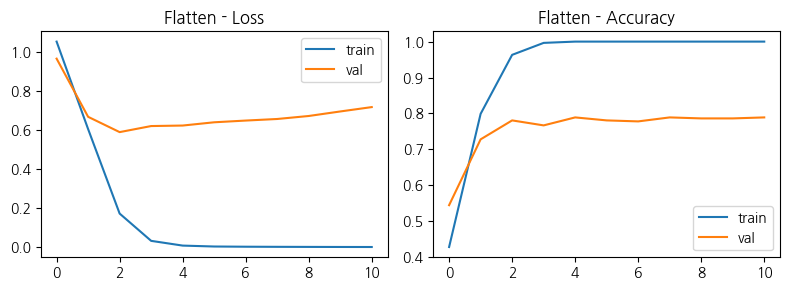

[Flatten] Test Accuracy: 0.792


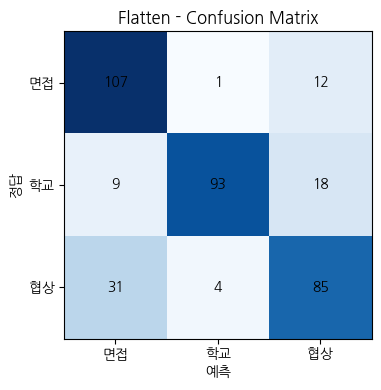

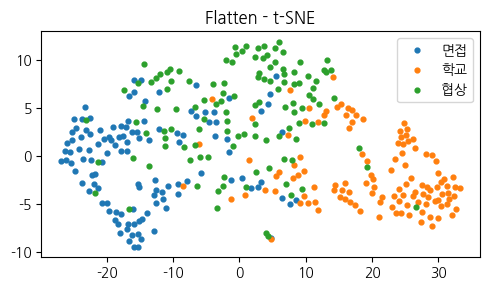

In [15]:
show_result(flat_model, h_flat, "Flatten")

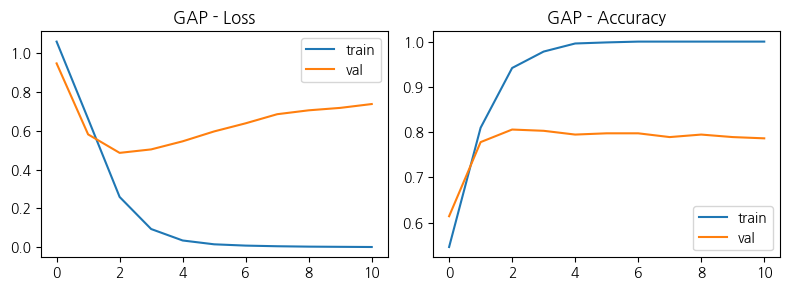

[GAP] Test Accuracy: 0.869


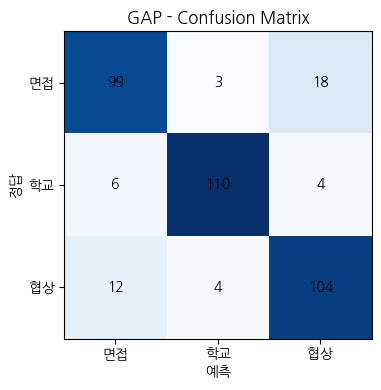

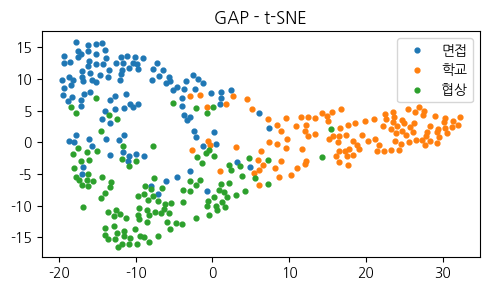

In [16]:
show_result(gap_model, h_gap, "GAP")

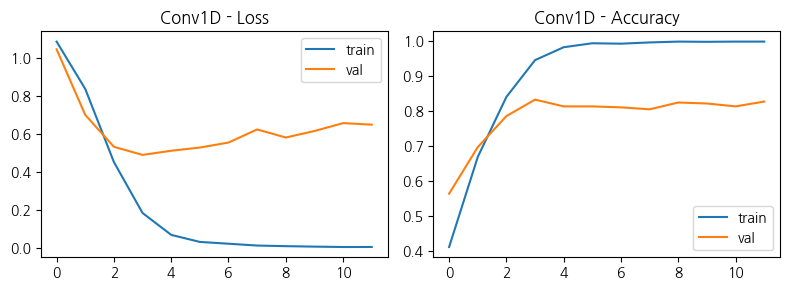

[Conv1D] Test Accuracy: 0.858


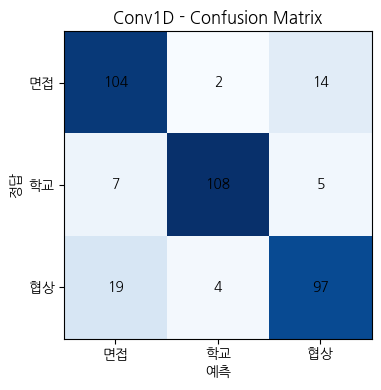

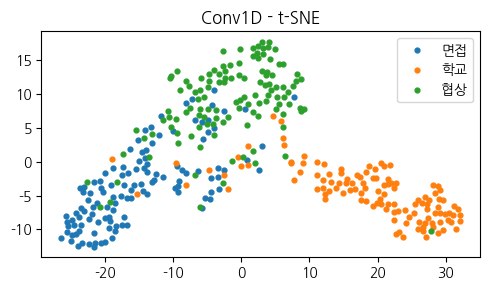

In [17]:
show_result(conv_model, h_conv, "Conv1D")

In [19]:
names = list(res.keys())

table = pd.DataFrame({
    "모델": names,
    "Test Accuracy": [res[n]["test_acc"] for n in names],
}).set_index("모델")

print(table.round(3))

         Test Accuracy
모델                    
Flatten          0.792
GAP              0.869
Conv1D           0.858


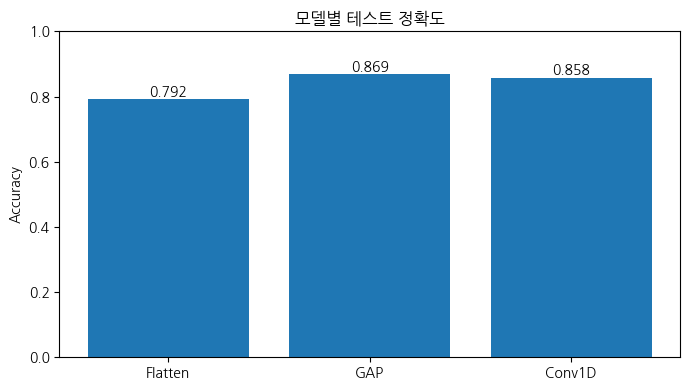

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(table.index, table["Test Accuracy"])
plt.ylim(0, 1)
plt.title("모델별 테스트 정확도")
plt.ylabel("Accuracy")
for i, v in enumerate(table["Test Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()